# Merge ClimActor, plant, PBL, and CAT ambition data

In [176]:
from pathlib import Path
import os

import pandas as pd

PROJECT_DIR = Path("/Users/wheeinner/Library/Mobile Documents/com~apple~CloudDocs/UNC/problem_shifting/Ambition")
os.chdir(PROJECT_DIR)

CLIMACTOR = Path("data_inter/ClimActor_ambition.2026_07_16.csv")
PBL = Path("data_inter/pbl_annualised_ambition_2026_07_14.csv")
CAT = Path("data_inter/CAT_annualised_ambition.2026_07_14.csv")

STEEL_PLANTS = Path("data_raw/steel_gdf_2026_05_18.csv")
CEMENT_PLANTS = Path("data_raw/cement_gdf_2026_07_07.csv")
POWER_PLANTS = Path("data_raw/cpp_finest_ADM_merged_by_gem_ids_CPP_2026.csv")

OUTPUT = Path("data_inter/merged.csv")
REGRESSION_RESULTS_DIR = PROJECT_DIR / "regression_results"
REGRESSION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [177]:
datacheck = Path("/Users/wheeinner/Downloads/data_inter_check.csv")
data = pd.read_csv(datacheck)
set(data["cement_presence"])
power_data = data.loc[data["power_presence"] == 1, "climactor_id"]
power_data.to_csv("power_presence_1.csv", index=False)

### 1. Read and clean the six input files

In [178]:
def read_source(path):
    data = pd.read_csv(path, low_memory=False)
    # Remove CSV index columns left by earlier exports.
    return data.loc[:, ~data.columns.str.match(r"^Unnamed:\s*\d*$")].copy()


climactor = read_source(CLIMACTOR)
pbl = read_source(PBL)
cat = read_source(CAT)
steel = read_source(STEEL_PLANTS)
cement = read_source(CEMENT_PLANTS)
power = read_source(POWER_PLANTS)

inputs = {
    "ClimActor": climactor,
    "PBL": pbl,
    "CAT": cat,
    "steel": steel,
    "cement": cement,
    "power": power,
}
pd.DataFrame(
    [{"source": name, "rows": len(data), "columns": data.shape[1]} for name, data in inputs.items()]
)

,source,rows,columns
0,ClimActor,2387,16
1,PBL,18,8
2,CAT,41,23
3,steel,1844,34
4,cement,3515,44
5,power,4942,64


### 2. Select the smallest administrative level for every plant

merge `GDAM_id` for the longest populated value among `GID_1` through `GID_5`.

In [179]:
GID_COLUMNS = [f"GID_{level}" for level in range(1, 6)]


def select_smallest_gdam_id(plants):
    """Return a copy with GDAM_id set to the longest non-null GID_* value per row."""
    available = [column for column in GID_COLUMNS if column in plants.columns]
    if not available:
        raise KeyError("No GID_1 ... GID_5 columns were found.")

    result = plants.copy()
    gids = result[available].astype("string").apply(lambda col: col.str.strip())
    gids = gids.replace("", pd.NA)

    result["GDAM_id"] = gids.apply(
        lambda row: max(row.dropna(), key=len) if row.notna().any() else pd.NA,
        axis=1,
    )
    result["selected_GID_level"] = gids.apply(
        lambda row: row.dropna().str.len().idxmax() if row.notna().any() else pd.NA,
        axis=1,
    )
    return result


steel_prepared = select_smallest_gdam_id(steel)
cement_prepared = select_smallest_gdam_id(cement)
power_prepared = select_smallest_gdam_id(power)

# For these four power-plant cases, also match at GID_3. The French case
# retains its already-matched GID_4 and receives an additional GID_3 row.
POWER_GID3_OVERRIDES = {
    "ZAF.3.3.1_1",
    "GBR.1.04.134",
    "DEU.9.34.6_1",
    "FRA.MA.200040715",
}
power_gid3 = power_prepared["GID_3"].astype("string").str.strip()
power_override_mask = power_gid3.isin(POWER_GID3_OVERRIDES)
matched_power_overrides = set(power_gid3.loc[power_override_mask].dropna().unique())
if matched_power_overrides != POWER_GID3_OVERRIDES:
    missing_overrides = sorted(POWER_GID3_OVERRIDES - matched_power_overrides)
    raise ValueError(f"Power GID_3 overrides not found: {missing_overrides}")

DUAL_LEVEL_POWER_GID3 = "FRA.MA.200040715"
power_dual_level_mask = power_gid3.eq(DUAL_LEVEL_POWER_GID3)
power_replacement_mask = power_override_mask & ~power_dual_level_mask

# Replace the normal longest-GID selection for the three non-French cases.
power_prepared.loc[power_replacement_mask, "GDAM_id"] = power_gid3.loc[power_replacement_mask]
power_prepared.loc[power_replacement_mask, "selected_GID_level"] = "GID_3"

# Append a second French row at GID_3 while preserving its original GID_4 row.
power_dual_level_rows = power_prepared.loc[power_dual_level_mask].copy()
power_dual_level_rows["GDAM_id"] = power_gid3.loc[power_dual_level_mask].to_numpy()
power_dual_level_rows["selected_GID_level"] = "GID_3"
power_prepared = pd.concat([power_prepared, power_dual_level_rows], ignore_index=True)

affected_power_locations = set(
    power.loc[power_override_mask, "GEM location ID"].dropna().unique()
)

power_prepared.loc[
    power_prepared["GEM location ID"].isin(affected_power_locations),
    ["GEM location ID", "GEM unit/phase ID", "GID_3", "GDAM_id", "selected_GID_level"],
].sort_values(["GEM location ID", "selected_GID_level"])

plant_selection = {
    "steel": steel_prepared,
    "cement": cement_prepared,
    "power": power_prepared,
}
pd.concat(
    [
        data["selected_GID_level"].value_counts(dropna=False).rename(name)
        for name, data in plant_selection.items()
    ],
    axis=1,
).fillna(0).astype(int)

,steel,cement,power
selected_GID_level,,,
<NA>,816,1927,0
GID_1,782,1297,242
GID_2,172,186,1504
GID_3,56,87,2858
GID_4,18,18,334
GID_5,0,0,5


### 3. Summarize plants by selected `GDAM_id`

industry presence/capacity: Steel capacity is crude-steel plus iron capacity; cement capacity is cement plus clinker capacity; power capacity is reported MW.

In [180]:
def summarize_industry(plants, industry, plant_id, capacity_columns):
    missing = [column for column in [plant_id, *capacity_columns] if column not in plants.columns]
    if missing:
        raise KeyError(f"Missing expected {industry} columns: {missing}")

    work = plants.dropna(subset=["GDAM_id"]).copy()
    capacity = work[capacity_columns].apply(pd.to_numeric, errors="coerce")
    work["_industry_capacity"] = capacity.sum(axis=1, min_count=1)

    summary = (
        work.groupby("GDAM_id", as_index=False)
        .agg(
            **{
                f"{industry}_plant_count": (plant_id, "nunique"),
                f"{industry}_capacity": ("_industry_capacity", "sum"),
            }
        )
    )
    summary[f"{industry}_presence"] = 1
    return summary


steel_summary = summarize_industry(
    steel_prepared,
    industry="steel",
    plant_id="GEM plant ID",
    capacity_columns=[
        "Nominal crude steel capacity (ttpa)",
        "Nominal iron capacity (ttpa)",
    ],
)
cement_summary = summarize_industry(
    cement_prepared,
    industry="cement",
    plant_id="GEM Plant ID",
    capacity_columns=[
        "Cement Capacity (millions metric tonnes per annum)",
        "Clinker Capacity (millions metric tonnes per annum)",
    ],
)
power_summary = summarize_industry(
    power_prepared,
    industry="power",
    plant_id="GEM location ID",
    capacity_columns=["Capacity (MW)"],
)

pd.DataFrame(
    {
        "industry": ["steel", "cement", "power"],
        "plant_rows_with_GDAM_id": [
            steel_prepared["GDAM_id"].notna().sum(),
            cement_prepared["GDAM_id"].notna().sum(),
            power_prepared["GDAM_id"].notna().sum(),
        ],
        "unique_selected_GDAM_ids": [
            len(steel_summary),
            len(cement_summary),
            len(power_summary),
        ],
    }
)

,industry,plant_rows_with_GDAM_id,unique_selected_GDAM_ids
0,steel,1028,219
1,cement,1588,363
2,power,4943,3005


### 4. Merge industry summaries into ClimActor

In [181]:
if climactor["GDAM_id"].isna().any():
    raise ValueError("ClimActor contains missing GDAM_id values.")
if climactor["GDAM_id"].duplicated().any():
    raise ValueError("ClimActor GDAM_id must be unique for one-to-one industry merges.")

merged = climactor.copy()
for summary in [steel_summary, cement_summary, power_summary]:
    merged = merged.merge(summary, on="GDAM_id", how="left", validate="one_to_one")

industry_columns = [
    column
    for column in merged.columns
    if column.endswith(("_presence", "_plant_count", "_capacity"))
]
merged[industry_columns] = merged[industry_columns].fillna(0)
for column in [c for c in industry_columns if c.endswith(("_presence", "_plant_count"))]:
    merged[column] = merged[column].astype("int64")

assert len(merged) == len(climactor)
merged[["GDAM_id", *industry_columns]].head()

,GDAM_id,steel_plant_count,steel_capacity,steel_presence,cement_plant_count,cement_capacity,cement_presence,power_plant_count,power_capacity,power_presence
0,ESP.09.08.08222,0,0.0,0,0,0.0,0,0,0.0,0
1,ITA.19.86.003,0,0.0,0,0,0.0,0,0,0.0,0
2,BEL.2.1.3.22_1,0,0.0,0,0,0.0,0,0,0.0,0
3,ITA.19.84.007,0,0.0,0,0,0.0,0,0,0.0,0
4,ITA.19.83.088,0,0.0,0,0,0.0,0,0,0.0,0


### 5. Merge PBL and CAT country data using `iso`

In [182]:
def prepare_country_source(data, key_column, prefix):
    result = data.rename(columns={key_column: "iso"}).copy()
    result["iso"] = result["iso"].astype("string").str.strip().str.upper()
    if result["iso"].isna().any():
        raise ValueError(f"{prefix.upper()} contains a missing country key.")
    if result["iso"].duplicated().any():
        duplicates = result.loc[result["iso"].duplicated(keep=False), "iso"].unique().tolist()
        raise ValueError(f"{prefix.upper()} has duplicate country keys: {duplicates}")

    return result.rename(
        columns={column: f"{prefix}_{column}" for column in result.columns if column != "iso"}
    )


pbl_country = prepare_country_source(pbl, key_column="ISO", prefix="pbl")
cat_country = prepare_country_source(cat, key_column="Country", prefix="cat")

merged["iso"] = merged["iso"].astype("string").str.strip().str.upper()
merged = merged.merge(pbl_country, on="iso", how="left", validate="many_to_one")
merged = merged.merge(cat_country, on="iso", how="left", validate="many_to_one")

assert len(merged) == len(climactor)
print(f"Final rows: {len(merged):,}; columns: {merged.shape[1]:,}")

Final rows: 2,387; columns: 54


### 6. Save the merged dataset

In [183]:
coverage = pd.DataFrame(
    {
        "source": ["steel", "cement", "power", "PBL", "CAT"],
        "matched_ClimActor_rows": [
            merged["steel_presence"].sum(),
            merged["cement_presence"].sum(),
            merged["power_presence"].sum(),
            merged["pbl_Country_name"].notna().sum(),
            merged["cat_Version"].notna().sum(),
        ],
    }
)
coverage

,source,matched_ClimActor_rows
0,steel,31
1,cement,43
2,power,47
3,PBL,150
4,CAT,314


In [184]:
OUTPUT.parent.mkdir(parents=True, exist_ok=True)
merged.to_csv(OUTPUT, index=False)

# Regression analysis

The four regressions:

- Type I uses annualised ambition and industry-presence indicators, with **no intercept**.
- Type II uses absolute/total ambition and industry capacities, with an **intercept**.
- The country-ambition-only subsample filters remain inactive, so every ClimActor row is used.
- CAT regressions continue to use the NDC Unconditional scenario.

In [185]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

### Annualised ambition distribution

The histogram shows the distribution of `annualised_ambition` for the same 2,387 ClimActor observations used by the regressions. Plan and neighbor-target distributions are shown at the end of the notebook.

In [186]:
regression_distributions = merged[["annualised_ambition"]].copy()
if regression_distributions["annualised_ambition"].isna().any():
    raise ValueError("annualised_ambition must not contain missing values.")
assert len(regression_distributions) == len(merged)

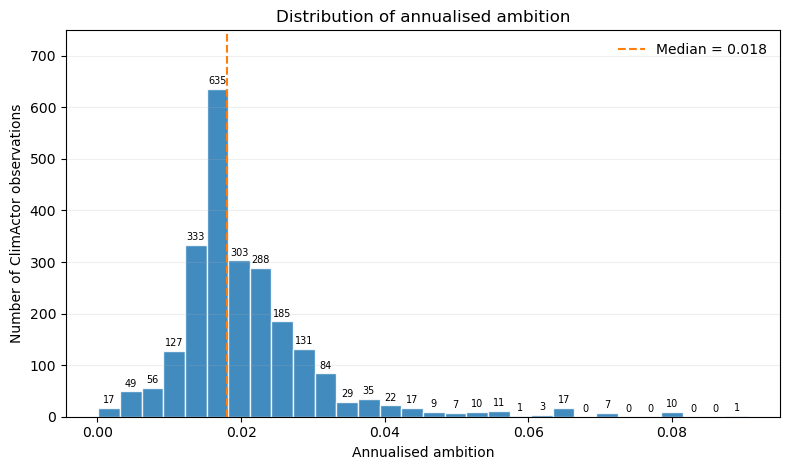

In [187]:
annualised_values = pd.to_numeric(
    regression_distributions["annualised_ambition"], errors="raise"
)

fig, ax = plt.subplots(figsize=(8, 4.8))
annualised_counts, _, annualised_bars = ax.hist(
    annualised_values, bins=30, color="C0", alpha=0.85, edgecolor="white"
)
ax.bar_label(
    annualised_bars,
    labels=[f"{int(count)}" for count in annualised_counts],
    padding=2,
    rotation=0,
    fontsize=7,
)
ax.axvline(
    annualised_values.median(),
    color="C1",
    linestyle="--",
    linewidth=1.5,
    label=f"Median = {annualised_values.median():.3f}",
)
ax.set(
    title="Distribution of annualised ambition",
    xlabel="Annualised ambition",
    ylabel="Number of ClimActor observations",
)
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False)
ax.set_ylim(top=annualised_counts.max() * 1.18)
fig.tight_layout()
plt.show()

### 7. Prepare PBL and CAT regression data

Missing country ambition values are assigned zero, and `country_ambition` indicates whether the relevant source value was originally available.

In [188]:
def add_PBL_country_ambition(climactor=merged):
    data_regression = climactor.copy()
    data_regression["annualised_geometric_ambition"] = data_regression["pbl_annualised_geometric_ambition"]
    data_regression["total_ambition"] = data_regression["pbl_total_ambition"]

    data_regression["country_ambition"] = np.where(
        data_regression["annualised_geometric_ambition"].isna(), 0, 1
    )
    data_regression["ISO"] = data_regression["GDAM_id"].str.split(".").str[0]
    data_regression[["annualised_geometric_ambition", "total_ambition"]] = (
        data_regression[["annualised_geometric_ambition", "total_ambition"]].fillna(0)
    )
    return data_regression


def add_CAT_country_ambition(climactor=merged):
    data_regression = climactor.copy()
    annualised_column = "NDC Unconditional_annualised_geometric_ambition"
    total_column = "NDC Unconditional_total_ambition"
    data_regression[annualised_column] = data_regression[f"cat_{annualised_column}"]
    data_regression[total_column] = data_regression[f"cat_{total_column}"]

    data_regression["country_ambition"] = np.where(
        data_regression[total_column].isna(), 0, 1
    )
    data_regression["iso"] = data_regression["GDAM_id"].str.split(".").str[0]
    data_regression[[annualised_column, total_column]] = (
        data_regression[[annualised_column, total_column]].fillna(0)
    )
    return data_regression

### 8. Type I regressions: annualised ambition and industry presence

No constant in both regressions.

In [189]:
def pbl_type_I_reg():
    data = add_PBL_country_ambition()
    data = data[[
        "ISO", "country_ambition", "annualised_geometric_ambition",
        "GDAM_id", "annualised_ambition", "power_presence",
        "steel_presence", "cement_presence",
    ]]
    data.to_csv(REGRESSION_RESULTS_DIR / "pbl_type_I_reg.csv")
    # Original subsample setting retained: no country_ambition == 1 filter.

    X = data[[
        "country_ambition", "annualised_geometric_ambition",
        "power_presence", "steel_presence", "cement_presence",
    ]]
    Y = data["annualised_ambition"]
    model = sm.OLS(Y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": data["ISO"]}
)  # No constant, cluster by country_id

    #print(data[[
    #    "power_presence", "steel_presence", "cement_presence",
    #    "country_ambition", "annualised_geometric_ambition",
    #]].corr())
    print(model.summary())
    return model


def cat_type_I_reg():
    data = add_CAT_country_ambition()
    annualised_column = "NDC Unconditional_annualised_geometric_ambition"
    data = data[[
        "iso", "country_ambition", annualised_column, "GDAM_id",
        "annualised_ambition", "power_presence", "steel_presence",
        "cement_presence",
    ]]
    data.to_csv(REGRESSION_RESULTS_DIR / "cat_type_I_reg.csv")
    # Original subsample setting retained: no country_ambition == 1 filter.

    X = data[[
        "country_ambition", annualised_column, "power_presence",
        "steel_presence", "cement_presence",
    ]]
    Y = data["annualised_ambition"]
    model = sm.OLS(Y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": data["iso"]}
)  # No constant, cluster by country_id

    #print(data[["power_presence", "steel_presence", "cement_presence"]].corr())
    print(model.summary())
    return model

In [190]:
pbl_type_I_model = pbl_type_I_reg()

                                 OLS Regression Results                                 
Dep. Variable:     annualised_ambition   R-squared (uncentered):                   0.142
Model:                             OLS   Adj. R-squared (uncentered):              0.140
Method:                  Least Squares   F-statistic:                              1515.
Date:                 Wed, 22 Jul 2026   Prob (F-statistic):                    3.86e-27
Time:                         13:59:13   Log-Likelihood:                          5769.7
No. Observations:                 2387   AIC:                                 -1.153e+04
Df Residuals:                     2382   BIC:                                 -1.150e+04
Df Model:                            5                                                  
Covariance Type:               cluster                                                  
                                    coef    std err          z      P>|z|      [0.025      0.975]
------------

In [191]:
cat_type_I_model = cat_type_I_reg()

                                 OLS Regression Results                                 
Dep. Variable:     annualised_ambition   R-squared (uncentered):                   0.222
Model:                             OLS   Adj. R-squared (uncentered):              0.220
Method:                  Least Squares   F-statistic:                              58.77
Date:                 Wed, 22 Jul 2026   Prob (F-statistic):                    5.47e-12
Time:                         13:59:15   Log-Likelihood:                          5886.5
No. Observations:                 2387   AIC:                                 -1.176e+04
Df Residuals:                     2382   BIC:                                 -1.173e+04
Df Model:                            5                                                  
Covariance Type:               cluster                                                  
                                                      coef    std err          z      P>|z|      [0.025      0

### 9. Type II regressions: total ambition and industry capacity

Both regressions include a constant.

In [192]:
def pbl_type_II_reg():
    data = add_PBL_country_ambition()
    data = data[[
        "ISO", "country_ambition", "total_ambition", "GDAM_id",
        "absolute_ambition", "power_capacity", "steel_capacity",
        "cement_capacity",
    ]]
    data.to_csv(REGRESSION_RESULTS_DIR / "pbl_type_II_reg.csv")
    # Original subsample setting retained: no country_ambition == 1 filter.

    X = data[[
        "country_ambition", "total_ambition", "power_capacity",
        "steel_capacity", "cement_capacity",
    ]]
    Y = data["absolute_ambition"]
    X = sm.add_constant(X)
    model = sm.OLS(Y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": data["ISO"]}
) 
    print(model.summary())
    return model


def cat_type_II_reg():
    data = add_CAT_country_ambition()
    total_column = "NDC Unconditional_total_ambition"
    data = data[[
        "iso", "country_ambition", total_column, "GDAM_id",
        "absolute_ambition", "power_capacity", "steel_capacity",
        "cement_capacity",
    ]]
    data.to_csv(REGRESSION_RESULTS_DIR / "cat_type_II_reg.csv")
    # Original subsample setting retained: no country_ambition == 1 filter.

    X = data[[
        "country_ambition", total_column, "power_capacity",
        "steel_capacity", "cement_capacity",
    ]]
    Y = data["absolute_ambition"]
    X = sm.add_constant(X)
    model = sm.OLS(Y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": data["iso"]}
) 

    #print(data[[
    #    "power_capacity", "steel_capacity", "cement_capacity",
    #    "country_ambition", total_column,
    #]].corr())
    print(model.summary())
    return model

In [193]:
pbl_type_II_model = pbl_type_II_reg()

                            OLS Regression Results                            
Dep. Variable:      absolute_ambition   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     73.79
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           5.34e-13
Time:                        13:59:20   Log-Likelihood:                -35514.
No. Observations:                2387   AIC:                         7.104e+04
Df Residuals:                    2381   BIC:                         7.108e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const             5.883e+04   3.18e+04  

In [194]:
cat_type_II_model = cat_type_II_reg()

                            OLS Regression Results                            
Dep. Variable:      absolute_ambition   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     51.14
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           2.22e-11
Time:                        13:59:22   Log-Likelihood:                -35457.
No. Observations:                2387   AIC:                         7.093e+04
Df Residuals:                    2381   BIC:                         7.096e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

### 10. Save the original regression results

Export four original models.

In [195]:
REGRESSION_RESULTS_DIR = Path("regression_results/")
REGRESSION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

original_models = {
    "pbl_type_I_original": pbl_type_I_model,
    "pbl_type_II_original": pbl_type_II_model,
    "cat_type_I_original": cat_type_I_model,
    "cat_type_II_original": cat_type_II_model,
}

original_coefficient_tables = []
for model_name, model in original_models.items():
    summary_path = REGRESSION_RESULTS_DIR / f"{model_name}_summary.txt"
    summary_path.write_text(model.summary().as_text(), encoding="utf-8")

    confidence_intervals = model.conf_int()
    original_coefficient_tables.append(
        pd.DataFrame(
            {
                "model": model_name,
                "term": model.params.index,
                "coefficient": model.params.values,
                "std_error": model.bse.values,
                "t_value": model.tvalues.values,
                "p_value": model.pvalues.values,
                "conf_int_low": confidence_intervals.iloc[:, 0].values,
                "conf_int_high": confidence_intervals.iloc[:, 1].values,
                "nobs": int(model.nobs),
                "r_squared": model.rsquared,
                "adjusted_r_squared": model.rsquared_adj,
                "aic": model.aic,
                "bic": model.bic,
            }
        )
    )

original_regression_results = pd.concat(original_coefficient_tables, ignore_index=True)
original_results_csv = REGRESSION_RESULTS_DIR / "original_regression_results.csv"
original_regression_results.to_csv(original_results_csv, index=False)

print(f"Saved {len(original_models)} original model summaries and {original_results_csv.resolve()}")
original_regression_results

Saved 4 original model summaries and /Users/wheeinner/Library/Mobile Documents/com~apple~CloudDocs/UNC/problem_shifting/Ambition/regression_results/original_regression_results.csv


,model,term,coefficient,std_error,t_value,p_value,conf_int_low,conf_int_high,nobs,r_squared,adjusted_r_squared,aic,bic
0,pbl_type_I_original,country_ambition,2.694446e-02,0.002580,10.444831,1.547314e-25,0.021888,3.200057e-02,2387,0.141857,0.140056,-11529.339445,-11500.450482
1,pbl_type_I_original,annualised_geometric_ambition,8.617587e-02,0.051935,1.659296,9.705617e-02,-0.015615,1.879670e-01,2387,0.141857,0.140056,-11529.339445,-11500.450482
2,pbl_type_I_original,power_presence,1.138530e-02,0.005410,2.104543,3.533113e-02,0.000782,2.198845e-02,2387,0.141857,0.140056,-11529.339445,-11500.450482
3,pbl_type_I_original,steel_presence,1.252310e-02,0.008248,1.518397,1.289144e-01,-0.003642,2.868805e-02,2387,0.141857,0.140056,-11529.339445,-11500.450482
4,pbl_type_I_original,cement_presence,1.291824e-02,0.003416,3.782078,1.555248e-04,0.006224,1.961278e-02,2387,0.141857,0.140056,-11529.339445,-11500.450482
5,pbl_type_II_original,const,5.883183e+04,31776.603588,1.851420,6.410918e-02,-3449.163922,1.211128e+05,2387,0.188111,0.186406,71040.940657,71075.607412
6,pbl_type_II_original,country_ambition,1.293977e+06,558212.176494,2.318074,2.044527e-02,199901.633345,2.388053e+06,2387,0.188111,0.186406,71040.940657,71075.607412
7,pbl_type_II_original,total_ambition,-4.850314e+01,229.211200,-0.211609,8.324121e-01,-497.748839,4.007426e+02,2387,0.188111,0.186406,71040.940657,71075.607412
8,pbl_type_II_original,power_capacity,9.953606e+02,613.392145,1.622715,1.046503e-01,-206.865876,2.197587e+03,2387,0.188111,0.186406,71040.940657,71075.607412
9,pbl_type_II_original,steel_capacity,-7.776503e+00,27.111265,-0.286837,7.742374e-01,-60.913606,4.536060e+01,2387,0.188111,0.186406,71040.940657,71075.607412


## Add ClimActor plan indicator and plan types

Only plan records with `plan_end_year >= 2027` are retained. The binary `plan` variable equals 1 when an actor has at least one qualifying record and 0 otherwise. Because an actor can report multiple qualifying plan types, unique `plan_type` values are combined into a semicolon-separated value before the one-to-one merge.

In [196]:
PLAN = Path("data_raw/ClimActor_6_plans.csv")
MERGED_PLAN_OUTPUT = Path("data_inter/merged_plan.csv")

plans = read_source(PLAN)
merged_for_plan = read_source(OUTPUT)

plans["plan_end_year"] = pd.to_numeric(plans["plan_end_year"], errors="coerce")
plans = plans.loc[plans["plan_end_year"].ge(2027)].copy()
assert plans["plan_end_year"].ge(2027).all()

plans["climactor_id"] = plans["climactor_id"].astype("string").str.strip()
plans["plan_type"] = plans["plan_type"].astype("string").str.strip().replace("", pd.NA)
merged_for_plan["climactor_id"] = (
    merged_for_plan["climactor_id"].astype("string").str.strip()
)

def combine_plan_types(values):
    unique_types = sorted(values.dropna().unique())
    return "; ".join(unique_types) if unique_types else pd.NA


plan_indicator_patterns = {
    "mitigation_plan": "mitigation",
    "integrated_plan": "integrated",
    "adaptation_plan": "adaptation",
}
for indicator, pattern in plan_indicator_patterns.items():
    plans[indicator] = (
        plans["plan_type"]
        .str.contains(pattern, case=False, regex=False, na=False)
        .astype("int64")
    )
plans["energy_plan"] = (
    plans["plan_type"]
    .str.casefold()
    .isin({"energy", "access to energy"})
    .astype("int64")
)
plan_type_indicator_columns = [*plan_indicator_patterns, "energy_plan"]


plan_types_by_actor = (
    plans.loc[plans["climactor_id"].notna(), ["climactor_id", "plan_type"]]
    .groupby("climactor_id", as_index=False)
    .agg(plan_type=("plan_type", combine_plan_types))
)
plan_indicators_by_actor = (
    plans.loc[
        plans["climactor_id"].notna(),
        ["climactor_id", *plan_type_indicator_columns],
    ]
    .groupby("climactor_id", as_index=False)
    .agg({indicator: "max" for indicator in plan_type_indicator_columns})
)
plan_lookup = (
    plans.loc[plans["climactor_id"].notna(), ["climactor_id"]]
    .drop_duplicates()
    .merge(plan_types_by_actor, on="climactor_id", how="left", validate="one_to_one")
    .merge(
        plan_indicators_by_actor,
        on="climactor_id",
        how="left",
        validate="one_to_one",
    )
    .assign(plan=1)
)

merged_plan = merged_for_plan.merge(
    plan_lookup,
    on="climactor_id",
    how="left",
    validate="one_to_one",
)
plan_indicator_columns = ["plan", *plan_type_indicator_columns]
merged_plan[plan_indicator_columns] = (
    merged_plan[plan_indicator_columns].fillna(0).astype("int64")
)

assert len(merged_plan) == len(merged_for_plan)
assert merged_plan["climactor_id"].is_unique
for column in plan_indicator_columns:
    assert set(merged_plan[column].unique()).issubset({0, 1})
for column in plan_type_indicator_columns:
    assert merged_plan[column].le(merged_plan["plan"]).all()
assert merged_plan.loc[merged_plan["plan"] == 0, "plan_type"].isna().all()

merged_plan.to_csv(MERGED_PLAN_OUTPUT, index=False)
print(
    f"Saved {len(merged_plan):,} rows to {MERGED_PLAN_OUTPUT.resolve()}; "
    f"{merged_plan['plan'].sum():,} actors have a plan and "
    f"{(merged_plan['plan'] == 0).sum():,} do not; "
    f"{merged_plan['plan_type'].notna().sum():,} have a reported plan type."
)

Saved 2,387 rows to /Users/wheeinner/Library/Mobile Documents/com~apple~CloudDocs/UNC/problem_shifting/Ambition/data_inter/merged_plan.csv; 1,596 actors have a plan and 791 do not; 1,596 have a reported plan type.


### 11. Rerun the four regressions with `integrated_plan` as an additional control

In [197]:
def pbl_type_I_reg_with_plan():
    data = add_PBL_country_ambition(climactor=merged_plan)
    data = data[[
        "ISO", "country_ambition", "annualised_geometric_ambition",
        "GDAM_id", "annualised_ambition", "power_presence",
        "steel_presence", "cement_presence", "integrated_plan",
    ]]
    data.to_csv(REGRESSION_RESULTS_DIR / "pbl_type_I_reg_plan.csv")
    # Original subsample setting retained: no country_ambition == 1 filter.

    X = data[[
        "country_ambition", "annualised_geometric_ambition",
        "power_presence", "steel_presence", "cement_presence", "integrated_plan",
    ]]
    Y = data["annualised_ambition"]
    model = sm.OLS(Y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": data["ISO"]}
)  # No constant, matching the original Type I model.

    #print(data[[
    #    "power_presence", "steel_presence", "cement_presence", "plan",
    #    "country_ambition", "annualised_geometric_ambition",
    #]].corr())
    print(model.summary())
    return model


def cat_type_I_reg_with_plan():
    data = add_CAT_country_ambition(climactor=merged_plan)
    annualised_column = "NDC Unconditional_annualised_geometric_ambition"
    data = data[[
        "iso", "country_ambition", annualised_column, "GDAM_id",
        "annualised_ambition", "power_presence", "steel_presence",
        "cement_presence", "integrated_plan",
    ]]
    data.to_csv(REGRESSION_RESULTS_DIR / "cat_type_I_reg_plan.csv")
    # Original subsample setting retained: no country_ambition == 1 filter.

    X = data[[
        "country_ambition", annualised_column, "power_presence",
        "steel_presence", "cement_presence", "integrated_plan",
    ]]
    Y = data["annualised_ambition"]
    model = sm.OLS(Y, X).fit(
        cov_type="cluster",
        cov_kwds={"groups": data["iso"]}
    )  # No constant, matching the original Type I model.

    #print(data[["power_presence", "steel_presence", "cement_presence", "plan"]].corr())
    print(model.summary())
    return model

In [23]:
pbl_type_I_plan_model = pbl_type_I_reg_with_plan()

                                 OLS Regression Results                                 
Dep. Variable:     annualised_ambition   R-squared (uncentered):                   0.619
Model:                             OLS   Adj. R-squared (uncentered):              0.618
Method:                  Least Squares   F-statistic:                              1013.
Date:                 Wed, 22 Jul 2026   Prob (F-statistic):                    1.04e-25
Time:                         13:56:24   Log-Likelihood:                          6739.9
No. Observations:                 2387   AIC:                                 -1.347e+04
Df Residuals:                     2381   BIC:                                 -1.343e+04
Df Model:                            6                                                  
Covariance Type:               cluster                                                  
                                    coef    std err          z      P>|z|      [0.025      0.975]
------------

In [198]:
cat_type_I_plan_model = cat_type_I_reg_with_plan()

                                 OLS Regression Results                                 
Dep. Variable:     annualised_ambition   R-squared (uncentered):                   0.669
Model:                             OLS   Adj. R-squared (uncentered):              0.668
Method:                  Least Squares   F-statistic:                              614.7
Date:                 Wed, 22 Jul 2026   Prob (F-statistic):                    2.46e-23
Time:                         13:59:42   Log-Likelihood:                          6907.1
No. Observations:                 2387   AIC:                                 -1.380e+04
Df Residuals:                     2381   BIC:                                 -1.377e+04
Df Model:                            6                                                  
Covariance Type:               cluster                                                  
                                                      coef    std err          z      P>|z|      [0.025      0

In [199]:
def pbl_type_II_reg_with_plan():
    data = add_PBL_country_ambition(climactor=merged_plan)
    data = data[[
        "ISO", "country_ambition", "total_ambition", "GDAM_id",
        "absolute_ambition", "power_capacity", "steel_capacity",
        "cement_capacity", "integrated_plan",
    ]]
    data.to_csv(REGRESSION_RESULTS_DIR / "pbl_type_II_reg_plan.csv")
    # Original subsample setting retained: no country_ambition == 1 filter.

    X = data[[
        "country_ambition", "total_ambition", "power_capacity",
        "steel_capacity", "cement_capacity", "integrated_plan",
    ]]
    Y = data["absolute_ambition"]
    X = sm.add_constant(X)
    model = sm.OLS(Y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": data["ISO"]}
) 
    print(model.summary())
    return model


def cat_type_II_reg_with_plan():
    data = add_CAT_country_ambition(climactor=merged_plan)
    total_column = "NDC Unconditional_total_ambition"
    data = data[[
        "iso", "country_ambition", total_column, "GDAM_id",
        "absolute_ambition", "power_capacity", "steel_capacity",
        "cement_capacity", "integrated_plan",
    ]]
    data.to_csv(REGRESSION_RESULTS_DIR / "cat_type_II_reg_plan.csv")
    # Original subsample setting retained: no country_ambition == 1 filter.

    X = data[[
        "country_ambition", total_column, "power_capacity",
        "steel_capacity", "cement_capacity", "integrated_plan"
    ]]
    Y = data["absolute_ambition"]
    X = sm.add_constant(X)
    model = sm.OLS(Y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": data["iso"]}
) 
    #print(data[[
    #    "power_capacity", "steel_capacity", "cement_capacity", "plan",
    #    "country_ambition", total_column,
    #]].corr())
    print(model.summary())
    return model

In [200]:
pbl_type_II_plan_model = pbl_type_II_reg_with_plan()

                            OLS Regression Results                            
Dep. Variable:      absolute_ambition   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     62.14
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.13e-12
Time:                        13:59:49   Log-Likelihood:                -35513.
No. Observations:                2387   AIC:                         7.104e+04
Df Residuals:                    2380   BIC:                         7.108e+04
Df Model:                           6                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const             3.062e+04   3.06e+04  

In [201]:
cat_type_II_plan_model = cat_type_II_reg_with_plan()

                            OLS Regression Results                            
Dep. Variable:      absolute_ambition   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     47.10
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.90e-11
Time:                        13:59:51   Log-Likelihood:                -35454.
No. Observations:                2387   AIC:                         7.092e+04
Df Residuals:                    2380   BIC:                         7.096e+04
Df Model:                           6                                         
Covariance Type:              cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

### 12. Save the plan-controlled regression results

Each model summary is saved as a text file. A combined CSV stores coefficients, uncertainty statistics, confidence intervals, sample size, and model fit statistics in a machine-readable form.

In [202]:
REGRESSION_RESULTS_DIR = Path("regression_results")
REGRESSION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plan_models = {
    "pbl_type_I_plan": pbl_type_I_plan_model,
    "pbl_type_II_plan": pbl_type_II_plan_model,
    "cat_type_I_plan": cat_type_I_plan_model,
    "cat_type_II_plan": cat_type_II_plan_model,
}

coefficient_tables = []
for model_name, model in plan_models.items():
    summary_path = REGRESSION_RESULTS_DIR / f"{model_name}_summary.txt"
    summary_path.write_text(model.summary().as_text(), encoding="utf-8")

    confidence_intervals = model.conf_int()
    coefficient_tables.append(
        pd.DataFrame(
            {
                "model": model_name,
                "term": model.params.index,
                "coefficient": model.params.values,
                "std_error": model.bse.values,
                "t_value": model.tvalues.values,
                "p_value": model.pvalues.values,
                "conf_int_low": confidence_intervals.iloc[:, 0].values,
                "conf_int_high": confidence_intervals.iloc[:, 1].values,
                "nobs": int(model.nobs),
                "r_squared": model.rsquared,
                "adjusted_r_squared": model.rsquared_adj,
                "aic": model.aic,
                "bic": model.bic,
            }
        )
    )

plan_regression_results = pd.concat(coefficient_tables, ignore_index=True)
results_csv = REGRESSION_RESULTS_DIR / "plan_controlled_regression_results.csv"
plan_regression_results.to_csv(results_csv, index=False)

print(f"Saved {len(plan_models)} plan model summaries and {results_csv.resolve()}")
plan_regression_results

Saved 4 plan model summaries and /Users/wheeinner/Library/Mobile Documents/com~apple~CloudDocs/UNC/problem_shifting/Ambition/regression_results/plan_controlled_regression_results.csv


,model,term,coefficient,std_error,t_value,p_value,conf_int_low,conf_int_high,nobs,r_squared,adjusted_r_squared,aic,bic
0,pbl_type_I_plan,country_ambition,1.909809e-02,0.004086,4.673554,2.960312e-06,0.011089,2.710731e-02,2387,0.619374,0.618415,-13467.861046,-13433.194290
1,pbl_type_I_plan,annualised_geometric_ambition,9.399311e-02,0.094937,0.990055,3.221475e-01,-0.092081,2.800668e-01,2387,0.619374,0.618415,-13467.861046,-13433.194290
2,pbl_type_I_plan,power_presence,2.850563e-03,0.003778,0.754489,4.505559e-01,-0.004554,1.025558e-02,2387,0.619374,0.618415,-13467.861046,-13433.194290
3,pbl_type_I_plan,steel_presence,6.025075e-03,0.005960,1.010851,3.120880e-01,-0.005657,1.770725e-02,2387,0.619374,0.618415,-13467.861046,-13433.194290
4,pbl_type_I_plan,cement_presence,5.743744e-03,0.002466,2.329138,1.985175e-02,0.000910,1.057709e-02,2387,0.619374,0.618415,-13467.861046,-13433.194290
5,pbl_type_I_plan,integrated_plan,2.083749e-02,0.000712,29.268412,2.618421e-188,0.019442,2.223288e-02,2387,0.619374,0.618415,-13467.861046,-13433.194290
6,pbl_type_II_plan,const,3.062301e+04,30613.462130,1.000312,3.171596e-01,-29378.275728,9.062429e+04,2387,0.188889,0.186844,71040.652518,71081.097066
7,pbl_type_II_plan,country_ambition,1.304244e+06,557758.260071,2.338368,1.936819e-02,211057.730919,2.397430e+06,2387,0.188889,0.186844,71040.652518,71081.097066
8,pbl_type_II_plan,total_ambition,-4.953093e+01,228.969987,-0.216321,8.287378e-01,-498.303857,3.992420e+02,2387,0.188889,0.186844,71040.652518,71081.097066
9,pbl_type_II_plan,power_capacity,9.823563e+02,609.222002,1.612477,1.068582e-01,-211.696905,2.176409e+03,2387,0.188889,0.186844,71040.652518,71081.097066


## Add Neighbor target indicator

The `nb_target_count` variable indicates the number of neighboring GDAMs that share a common boundary and also have a target, ranging from 0 to 23.

The models retain the previous `plan` control and add `nb_target_count` as one additional control.

### 13. Merge neighbors and parents to cities

Join `CITIES.GDAM_id` to `PARENT.child_GID`.

Merge neighbors data using `climactor_id`

In [203]:
WORKSPACE = Path("/Users/wheeinner/Library/Mobile Documents/com~apple~CloudDocs/UNC/problem_shifting/Ambition")
UNIQUE_OUTPUT_PATH = WORKSPACE / "data_inter" / "merged_parent_nbs_unique.csv"
FINAL_MERGED_OUTPUT_PATH = WORKSPACE / "data_inter" / "merged_plan_nbs.csv"

CITIES_PATH = WORKSPACE / "data_inter" / "ClimActor_ambition.2026_07_16.csv"
PARENT_PATH = WORKSPACE / "data_raw" / "parent_children_exploded.csv"
NBS_PATH = WORKSPACE / "data_raw" / "nbs_merged_long.csv"
OUTPUT_PATH = WORKSPACE / "data_inter" / "merged_parent_nbs.csv"

cities = pd.read_csv(CITIES_PATH, low_memory=False)
parent = pd.read_csv(PARENT_PATH, low_memory=False)
nbs = pd.read_csv(NBS_PATH, low_memory=False)

# merge parents
required_columns = {
    "CITIES": (cities, ["GDAM_id", "climactor_id"]),
    "PARENT": (parent, ["child_GID", "parent_id"]),
    "NBS": (nbs, ["climactor_id"]),
}
for dataset_name, (data, columns) in required_columns.items():
    missing = [column for column in columns if column not in data.columns]
    if missing:
        raise KeyError(f"{dataset_name} is missing required columns: {missing}")

if parent["child_GID"].duplicated().any():
    raise ValueError("PARENT.child_GID is not unique; the parent merge would multiply CITIES rows.")

cities_parent = cities.merge(
    parent,
    how="left",
    left_on="GDAM_id",
    right_on="child_GID",
    validate="many_to_one",
    indicator="_parent_merge",
)

parent_match_counts = cities_parent["_parent_merge"].value_counts()
print(parent_match_counts)
print(f"Rows after parent merge: {len(cities_parent):,}")
print(f"Rows without parent_id: {cities_parent['parent_id'].isna().sum():,}")

# merge neighbors
if cities_parent["parent_id"].isna().any():
    print("Warning: some CITIES rows did not match a parent_id.")

cities_parent = cities_parent.drop(columns=["_parent_merge"])
cities_parent.head()


if cities_parent["climactor_id"].duplicated().any():
    raise ValueError("CITIES climactor_id is not unique before the one-to-many NBS merge.")

merged_parent_nbs = cities_parent.merge(
    nbs,
    how="left",
    on="climactor_id",
    suffixes=("", "_nbs"),
    validate="one_to_many",
    indicator="_nbs_merge",
)

nbs_match_counts = merged_parent_nbs["_nbs_merge"].value_counts()
unmatched_nbs_entities = merged_parent_nbs.loc[
    merged_parent_nbs["_nbs_merge"].eq("left_only"), "climactor_id"
].nunique()
print(nbs_match_counts)
print(f"Rows after NBS merge: {len(merged_parent_nbs):,}")
print(f"Unique CITIES entities retained: {merged_parent_nbs['climactor_id'].nunique():,}")
print(f"CITIES entities without an NBS match: {unmatched_nbs_entities:,}")

merged_parent_nbs = merged_parent_nbs.drop(columns=["_nbs_merge"])
merged_parent_nbs.head()

# group unique cities and count neighbors with targets
group_columns = [
    "iso",
    "entity_type",
    "climactor_id",
    "baseline_value",
    "baseline_year",
    "inv_year",
    "target_year",
    "target_value",
    "target_record",
    "GDAM_id",
    "target_year_emission",
    "annualised_ambition_from_baseline",
    "annualised_ambition",
    "2019_emissions_for_total_ambition",
    "2030_emissions",
    "absolute_ambition",
    "parent_id",
    "parent_level",
    "neighbor_count",
]

required_group_columns = group_columns + ["neighbor_has_target"]
missing_group_columns = [
    column for column in required_group_columns if column not in merged_parent_nbs.columns
]
if missing_group_columns:
    raise KeyError(f"Merged data is missing requested columns: {missing_group_columns}")

grouping_data = merged_parent_nbs[required_group_columns].copy()
grouping_data["_neighbor_has_target"] = (
    grouping_data["neighbor_has_target"]
    .astype("string")
    .str.strip()
    .str.lower()
    .isin(["true", "1", "yes"])
)

merged_parent_nbs_unique = (
    grouping_data
    .groupby(group_columns, dropna=False, as_index=False)
    .agg(nb_target_count=("_neighbor_has_target", "sum"))
)
merged_parent_nbs_unique["nb_target_count"] = (
    merged_parent_nbs_unique["nb_target_count"].astype("int64")
)
merged_parent_nbs_unique.to_csv(UNIQUE_OUTPUT_PATH, index=False)

assert list(merged_parent_nbs_unique.columns) == group_columns + ["nb_target_count"]
assert not merged_parent_nbs_unique.duplicated(subset=group_columns).any()
assert merged_parent_nbs_unique["nb_target_count"].ge(0).all()
assert (
    merged_parent_nbs_unique["neighbor_count"].isna()
    | merged_parent_nbs_unique["nb_target_count"].le(
        merged_parent_nbs_unique["neighbor_count"]
    )
).all()
print(f"Rows before grouping: {len(merged_parent_nbs):,}")
print(f"Grouped rows saved: {len(merged_parent_nbs_unique):,}")
print(merged_parent_nbs_unique["nb_target_count"].describe())
print(f"Unique climactor_id values retained: {merged_parent_nbs_unique['climactor_id'].nunique():,}")
print(f"Saved to: {UNIQUE_OUTPUT_PATH}")

# Merge the grouped parent and neighbor fields into the plan/industry/country dataset.
parent_neighbor_columns = [
    "climactor_id",
    "parent_id",
    "parent_level",
    "neighbor_count",
    "nb_target_count",
]
parent_neighbor_lookup = merged_parent_nbs_unique[parent_neighbor_columns].copy()
if parent_neighbor_lookup["climactor_id"].duplicated().any():
    raise ValueError("Grouped parent/neighbor data must have one row per climactor_id.")

merged_plan = (
    merged_plan
    .drop(columns=parent_neighbor_columns[1:], errors="ignore")
    .merge(
        parent_neighbor_lookup,
        on="climactor_id",
        how="left",
        validate="one_to_one",
    )
)

assert len(merged_plan) == len(merged_for_plan)
assert merged_plan["climactor_id"].is_unique
if merged_plan["nb_target_count"].isna().any():
    raise ValueError("Final merged data contains missing nb_target_count values.")
merged_plan["nb_target_count"] = merged_plan["nb_target_count"].astype("int64")
merged_plan.to_csv(FINAL_MERGED_OUTPUT_PATH, index=False)
print(f"Final merged rows saved: {len(merged_plan):,}")
print(f"Final merged data saved to: {FINAL_MERGED_OUTPUT_PATH}")
merged_plan.head()

_parent_merge
both          2387
left_only        0
right_only       0
Name: count, dtype: int64
Rows after parent merge: 2,387
Rows without parent_id: 0
_nbs_merge
both          10927
left_only         1
right_only        0
Name: count, dtype: int64
Rows after NBS merge: 10,928
Unique CITIES entities retained: 2,387
CITIES entities without an NBS match: 1
Rows before grouping: 10,928
Grouped rows saved: 2,387
count    2387.000000
mean        2.875576
std         2.193877
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        23.000000
Name: nb_target_count, dtype: float64
Unique climactor_id values retained: 2,387
Saved to: /Users/wheeinner/Library/Mobile Documents/com~apple~CloudDocs/UNC/problem_shifting/Ambition/data_inter/merged_parent_nbs_unique.csv
Final merged rows saved: 2,387
Final merged data saved to: /Users/wheeinner/Library/Mobile Documents/com~apple~CloudDocs/UNC/problem_shifting/Ambition/data_inter/merged_plan_nbs.csv


,iso,entity_type,climactor_id,baseline_value,baseline_year,inv_year,target_year,target_value,target_record,GDAM_id,...,plan_type,mitigation_plan,integrated_plan,adaptation_plan,energy_plan,plan,parent_id,parent_level,neighbor_count,nb_target_count
0,ESP,City,00752000db04c515,11423.000,2005,2014.0,2030,40.0,00752000db04c515_2030,ESP.09.08.08222,...,<NA>,0,0,0,0,0,ESP.09.08,ADM2,3.0,3
1,ITA,City,0083ef4ed71b869e,7739.785,2011,2011.0,2030,40.0,0083ef4ed71b869e_2030,ITA.19.86.003,...,<NA>,0,0,0,0,0,ITA.19.86,ADM2,6.0,4
2,BEL,City,00887dae5af7b824,48759.200,2011,2020.0,2030,40.0,00887dae5af7b824_2030,BEL.2.1.3.22_1,...,Integrated,0,1,0,0,1,BEL.2.1.3_1,ADM3,5.0,5
3,ITA,City,00b3f9e9c6778784,8965.400,2011,2011.0,2030,40.0,00b3f9e9c6778784_2030,ITA.19.84.007,...,Integrated,0,1,0,0,1,ITA.19.84,ADM2,5.0,5
4,ITA,City,00db591fd214bead,7876.169,2011,2011.0,2030,40.0,00db591fd214bead_2030,ITA.19.83.088,...,<NA>,0,0,0,0,0,ITA.19.83,ADM2,1.0,1


In [204]:
required_neighbor_columns = {"integrated_plan", "nb_target_count"}
missing_neighbor_columns = required_neighbor_columns.difference(merged_plan.columns)
if missing_neighbor_columns:
    raise KeyError(f"merged_plan is missing required columns: {sorted(missing_neighbor_columns)}")
if merged_plan[["integrated_plan", "nb_target_count"]].isna().any().any():
    raise ValueError("integrated_plan and nb_target_count must be complete before regression.")


def pbl_type_I_reg_with_plan_nbs():
    data = add_PBL_country_ambition(climactor=merged_plan)
    data = data[[
        "ISO", "country_ambition", "annualised_geometric_ambition",
        "GDAM_id", "annualised_ambition", "power_presence",
        "steel_presence", "cement_presence", "integrated_plan", "nb_target_count"
    ]]
    data.to_csv(REGRESSION_RESULTS_DIR / "pbl_type_I_reg_with_plan_nbs.csv")
    # Original subsample setting retained: no country_ambition == 1 filter.

    X = data[[
        "country_ambition", "annualised_geometric_ambition",
        "power_presence", "steel_presence", "cement_presence", "integrated_plan",
        "nb_target_count"
    ]]
    Y = data["annualised_ambition"]
    model = sm.OLS(Y, X).fit()  # No constant, matching the original Type I model.

    #print(data[[
    #    "power_presence", "steel_presence", "cement_presence", "plan",
    #    "country_ambition", "annualised_geometric_ambition",
    #]].corr())
    print(model.summary())
    return model


def cat_type_I_reg_with_plan_nbs():
    data = add_CAT_country_ambition(climactor=merged_plan)
    annualised_column = "NDC Unconditional_annualised_geometric_ambition"
    data = data[[
        "iso", "country_ambition", annualised_column, "GDAM_id",
        "annualised_ambition", "power_presence", "steel_presence",
        "cement_presence", "integrated_plan", "nb_target_count"
    ]]
    data.to_csv(REGRESSION_RESULTS_DIR / "cat_type_I_reg_with_plan_nbs.csv")
    # Original subsample setting retained: no country_ambition == 1 filter.

    X = data[[
        "country_ambition", annualised_column, "power_presence",
        "steel_presence", "cement_presence", "integrated_plan", "nb_target_count"
    ]]
    Y = data["annualised_ambition"]
    model = sm.OLS(Y, X).fit()  # No constant, matching the original Type I model.

    #print(data[["power_presence", "steel_presence", "cement_presence", "plan"]].corr())
    print(model.summary())
    return model

In [205]:
pbl_type_I_plan_nbs_model = pbl_type_I_reg_with_plan_nbs()

                                 OLS Regression Results                                 
Dep. Variable:     annualised_ambition   R-squared (uncentered):                   0.708
Model:                             OLS   Adj. R-squared (uncentered):              0.707
Method:                  Least Squares   F-statistic:                              825.2
Date:                 Wed, 22 Jul 2026   Prob (F-statistic):                        0.00
Time:                         14:00:09   Log-Likelihood:                          7057.1
No. Observations:                 2387   AIC:                                 -1.410e+04
Df Residuals:                     2380   BIC:                                 -1.406e+04
Df Model:                            7                                                  
Covariance Type:             nonrobust                                                  
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------

In [206]:
cat_type_I_plan_nbs_model = cat_type_I_reg_with_plan_nbs()

                                 OLS Regression Results                                 
Dep. Variable:     annualised_ambition   R-squared (uncentered):                   0.764
Model:                             OLS   Adj. R-squared (uncentered):              0.764
Method:                  Least Squares   F-statistic:                              1103.
Date:                 Wed, 22 Jul 2026   Prob (F-statistic):                        0.00
Time:                         14:00:11   Log-Likelihood:                          7312.0
No. Observations:                 2387   AIC:                                 -1.461e+04
Df Residuals:                     2380   BIC:                                 -1.457e+04
Df Model:                            7                                                  
Covariance Type:             nonrobust                                                  
                                                      coef    std err          t      P>|t|      [0.025      0

### Type II regressions with plan and neighboring-target controls

These models keep the original Type II specification, including the intercept, and add `nb_target_count` alongside `plan`.

In [207]:
def pbl_type_II_reg_with_plan_nbs():
    data = add_PBL_country_ambition(climactor=merged_plan)
    data = data[[
        "ISO", "country_ambition", "total_ambition", "GDAM_id",
        "absolute_ambition", "power_capacity", "steel_capacity",
        "cement_capacity", "integrated_plan", "nb_target_count",
    ]]
    data.to_csv(REGRESSION_RESULTS_DIR / "pbl_type_II_reg_with_plan_nbs.csv")
    # Original subsample setting retained: no country_ambition == 1 filter.

    X = data[[
        "country_ambition", "total_ambition", "power_capacity",
        "steel_capacity", "cement_capacity", "integrated_plan",
        "nb_target_count",
    ]]
    Y = data["absolute_ambition"]
    X = sm.add_constant(X)
    model = sm.OLS(Y, X).fit()
    print(model.summary())
    return model


def cat_type_II_reg_with_plan_nbs():
    data = add_CAT_country_ambition(climactor=merged_plan)
    total_column = "NDC Unconditional_total_ambition"
    data = data[[
        "iso", "country_ambition", total_column, "GDAM_id",
        "absolute_ambition", "power_capacity", "steel_capacity",
        "cement_capacity", "integrated_plan", "nb_target_count",
    ]]
    data.to_csv(REGRESSION_RESULTS_DIR / "cat_type_II_reg_with_plan_nbs.csv")
    # Original subsample setting retained: no country_ambition == 1 filter.

    X = data[[
        "country_ambition", total_column, "power_capacity",
        "steel_capacity", "cement_capacity", #"integrated_plan",
        #"nb_target_count",
    ]]
    Y = data["absolute_ambition"]
    X = sm.add_constant(X)
    model = sm.OLS(Y, X).fit()
    print(model.summary())
    return model

In [208]:
pbl_type_II_plan_nbs_model = pbl_type_II_reg_with_plan_nbs()

                            OLS Regression Results                            
Dep. Variable:      absolute_ambition   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     79.15
Date:                Wed, 22 Jul 2026   Prob (F-statistic):          1.62e-103
Time:                        14:00:16   Log-Likelihood:                -35513.
No. Observations:                2387   AIC:                         7.104e+04
Df Residuals:                    2379   BIC:                         7.109e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2.761e+04   3.15e+04  

In [209]:
cat_type_II_plan_nbs_model = cat_type_II_reg_with_plan_nbs()

                            OLS Regression Results                            
Dep. Variable:      absolute_ambition   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     139.5
Date:                Wed, 22 Jul 2026   Prob (F-statistic):          4.98e-130
Time:                        14:00:19   Log-Likelihood:                -35457.
No. Observations:                2387   AIC:                         7.093e+04
Df Residuals:                    2381   BIC:                         7.096e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

### Save plan and neighboring-target regression results

The four model summaries and a combined coefficient table are saved in `regression_results/`, alongside the four regression-input CSV files.

In [210]:
plan_nbs_models = {
    "pbl_type_I_plan_nbs": pbl_type_I_plan_nbs_model,
    "pbl_type_II_plan_nbs": pbl_type_II_plan_nbs_model,
    "cat_type_I_plan_nbs": cat_type_I_plan_nbs_model,
    "cat_type_II_plan_nbs": cat_type_II_plan_nbs_model,
}

plan_nbs_coefficient_tables = []
for model_name, model in plan_nbs_models.items():
    summary_path = REGRESSION_RESULTS_DIR / f"{model_name}_summary.txt"
    summary_path.write_text(model.summary().as_text(), encoding="utf-8")

    confidence_intervals = model.conf_int()
    plan_nbs_coefficient_tables.append(
        pd.DataFrame(
            {
                "model": model_name,
                "term": model.params.index,
                "coefficient": model.params.values,
                "std_error": model.bse.values,
                "t_value": model.tvalues.values,
                "p_value": model.pvalues.values,
                "conf_int_low": confidence_intervals.iloc[:, 0].values,
                "conf_int_high": confidence_intervals.iloc[:, 1].values,
                "nobs": int(model.nobs),
                "r_squared": model.rsquared,
                "adjusted_r_squared": model.rsquared_adj,
                "aic": model.aic,
                "bic": model.bic,
            }
        )
    )

plan_nbs_regression_results = pd.concat(plan_nbs_coefficient_tables, ignore_index=True)
plan_nbs_results_csv = (
    REGRESSION_RESULTS_DIR / "plan_nbs_controlled_regression_results.csv"
)
plan_nbs_regression_results.to_csv(plan_nbs_results_csv, index=False)

print(f"Saved {len(plan_nbs_models)} model summaries and {plan_nbs_results_csv.resolve()}")
plan_nbs_regression_results

Saved 4 model summaries and /Users/wheeinner/Library/Mobile Documents/com~apple~CloudDocs/UNC/problem_shifting/Ambition/regression_results/plan_nbs_controlled_regression_results.csv


,model,term,coefficient,std_error,t_value,p_value,conf_int_low,conf_int_high,nobs,r_squared,adjusted_r_squared,aic,bic
0,pbl_type_I_plan_nbs,country_ambition,2.225760e-02,0.002460,9.047944,2.948631e-19,1.743371e-02,2.708150e-02,2387,0.708206,0.707348,-14100.251100,-14059.806551
1,pbl_type_I_plan_nbs,annualised_geometric_ambition,7.899260e-02,0.064041,1.233471,2.175219e-01,-4.658914e-02,2.045743e-01,2387,0.708206,0.707348,-14100.251100,-14059.806551
2,pbl_type_I_plan_nbs,power_presence,3.412243e-03,0.001954,1.746501,8.085292e-02,-4.190035e-04,7.243489e-03,2387,0.708206,0.707348,-14100.251100,-14059.806551
3,pbl_type_I_plan_nbs,steel_presence,1.999638e-03,0.002350,0.850842,3.949430e-01,-2.608991e-03,6.608268e-03,2387,0.708206,0.707348,-14100.251100,-14059.806551
4,pbl_type_I_plan_nbs,cement_presence,2.175769e-03,0.001979,1.099163,2.718082e-01,-1.705911e-03,6.057448e-03,2387,0.708206,0.707348,-14100.251100,-14059.806551
5,pbl_type_I_plan_nbs,integrated_plan,1.340406e-02,0.000433,30.935274,6.583146e-177,1.255439e-02,1.425373e-02,2387,0.708206,0.707348,-14100.251100,-14059.806551
6,pbl_type_I_plan_nbs,nb_target_count,2.517040e-03,0.000094,26.917494,1.502798e-139,2.333672e-03,2.700409e-03,2387,0.708206,0.707348,-14100.251100,-14059.806551
7,pbl_type_II_plan_nbs,const,2.760541e+04,31492.562770,0.876569,3.808092e-01,-3.415030e+04,8.936111e+04,2387,0.188896,0.186510,71042.630786,71088.853127
8,pbl_type_II_plan_nbs,country_ambition,1.307127e+06,113062.885679,11.561061,4.074590e-30,1.085415e+06,1.528839e+06,2387,0.188896,0.186510,71042.630786,71088.853127
9,pbl_type_II_plan_nbs,total_ambition,-4.965927e+01,49.203896,-1.009255,3.129550e-01,-1.461462e+02,4.682768e+01,2387,0.188896,0.186510,71042.630786,71088.853127


## Distributions of plan and neighboring-target variables

The tables show the plan and neighboring-target count summaries. 

The plots show the categorical distribution of reported plan types and the integer distribution of `nb_target_count`.

In [211]:
plan_counts = merged_plan["plan"].value_counts().reindex([0, 1], fill_value=0)
plan_distribution = plan_counts.rename_axis("plan").reset_index(name="count")
plan_distribution["plan_status"] = plan_distribution["plan"].map(
    {0: "No plan", 1: "Has plan"}
)
plan_distribution["percent"] = (
    100 * plan_distribution["count"] / plan_distribution["count"].sum()
)
plan_distribution = plan_distribution[["plan", "plan_status", "count", "percent"]]

max_neighbor_targets = int(merged_plan["nb_target_count"].max())
neighbor_counts = (
    merged_plan["nb_target_count"]
    .astype("int64")
    .value_counts()
    .reindex(range(max_neighbor_targets + 1), fill_value=0)
)
neighbor_target_distribution = (
    neighbor_counts.rename_axis("nb_target_count").reset_index(name="count")
)
neighbor_target_distribution["percent"] = (
    100 * neighbor_target_distribution["count"] / neighbor_target_distribution["count"].sum()
)
neighbor_target_distribution["cumulative_percent"] = (
    neighbor_target_distribution["percent"].cumsum()
)

display(
    plan_distribution.style
    .hide(axis="index")
    .format({"percent": "{:.2f}%"})
    .set_caption("Distribution of plan availability")
)
display(
    neighbor_target_distribution.style
    .hide(axis="index")
    .format({"percent": "{:.2f}%", "cumulative_percent": "{:.2f}%"})
    .set_caption("Distribution of neighboring target counts")
)

plan,plan_status,count,percent
0,No plan,791,33.14%
1,Has plan,1596,66.86%


nb_target_count,count,percent,cumulative_percent
0,389,16.30%,16.30%
1,291,12.19%,28.49%
2,393,16.46%,44.95%
3,449,18.81%,63.76%
4,417,17.47%,81.23%
5,203,8.50%,89.74%
6,118,4.94%,94.68%
7,66,2.76%,97.44%
8,31,1.30%,98.74%
9,7,0.29%,99.04%


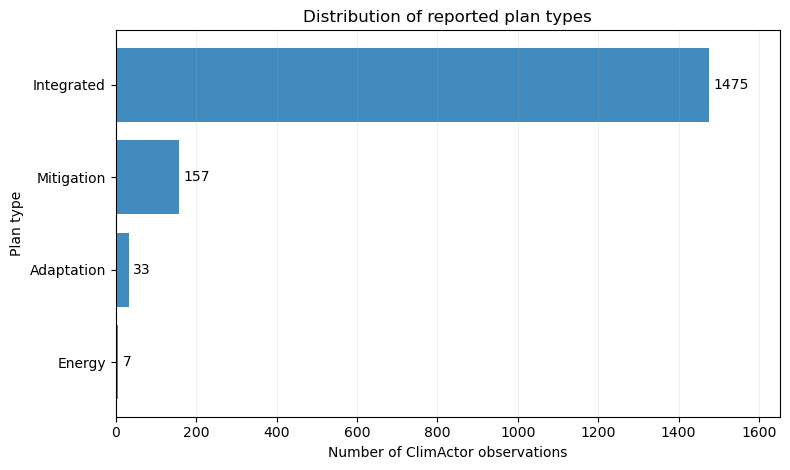

In [212]:
current_actor_ids = set(merged_plan["climactor_id"].dropna())
plan_type_actor_pairs = (
    plans.loc[
        plans["climactor_id"].isin(current_actor_ids),
        ["climactor_id", "plan_type"],
    ]
    .dropna(subset=["plan_type"])
    .drop_duplicates()
)
plan_type_distribution = (
    plan_type_actor_pairs["plan_type"]
    .value_counts()
    .rename_axis("plan_type")
    .reset_index(name="actor_count")
    .sort_values("actor_count")
)

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.barh(
    plan_type_distribution["plan_type"],
    plan_type_distribution["actor_count"],
    color="C0",
    alpha=0.85,
)
ax.bar_label(bars, padding=3, fmt="%d")
ax.set(
    title="Distribution of reported plan types",
    xlabel="Number of ClimActor observations",
    ylabel="Plan type",
)
ax.grid(axis="x", alpha=0.2)
ax.set_xlim(right=plan_type_distribution["actor_count"].max() * 1.12)
fig.tight_layout()
plt.show()

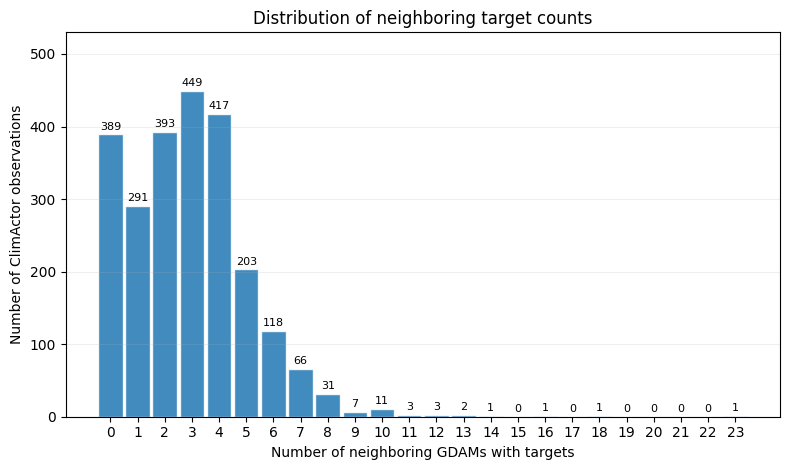

In [39]:
neighbor_target_values = merged_plan["nb_target_count"].astype("int64")
neighbor_bins = np.arange(
    neighbor_target_values.min() - 0.5,
    neighbor_target_values.max() + 1.5,
    1,
)

fig, ax = plt.subplots(figsize=(8, 4.8))
neighbor_hist_counts, _, neighbor_bars = ax.hist(
    neighbor_target_values,
    bins=neighbor_bins,
    color="C0",
    alpha=0.85,
    edgecolor="white",
    rwidth=0.9,
)
ax.bar_label(
    neighbor_bars,
    labels=[f"{int(count)}" for count in neighbor_hist_counts],
    padding=2,
    rotation=0,
    fontsize=8,
)
ax.set(
    title="Distribution of neighboring target counts",
    xlabel="Number of neighboring GDAMs with targets",
    ylabel="Number of ClimActor observations",
)
ax.set_xticks(range(neighbor_target_values.min(), neighbor_target_values.max() + 1))
ax.grid(axis="y", alpha=0.2)
ax.set_ylim(top=neighbor_hist_counts.max() * 1.18)
fig.tight_layout()
plt.show()